In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

***data importing***

In [4]:
print("--- Loading Datasets ---")
train = pd.read_csv('/content/drive/MyDrive/TAHMO Incoming Solar Radiation Prediction Challenge/Train.csv')
test = pd.read_csv('/content/drive/MyDrive/TAHMO Incoming Solar Radiation Prediction Challenge/Test.csv')
tropomi = pd.read_csv('/content/drive/MyDrive/TAHMO Incoming Solar Radiation Prediction Challenge/TROPOMI_Cloud_Fraction_TAHMO.csv')

--- Loading Datasets ---


In [5]:
print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"TROPOMI shape: {tropomi.shape}")

print("\nTrain Data Head:")
display(train.head(3))

Train shape: (642175, 13)
Test shape: (683353, 12)
TROPOMI shape: (385, 3)

Train Data Head:


,ID,timestamp,precipitation (mm),radiation (W/m2),relativehumidity (-),temperature (degrees Celsius),station,station_name,country,installation_height,elevation,latitude,longitude
0,cd7ebf43_2018-01_VAH5X7,2018-01-20 08:15:00,0.0,224.0,0.319,17.3,TA00349,Lycee De Mopti,ML,2.0,271.0,14.49461,-4.188941
1,cd7ebf43_2018-01_YWVE4N,2018-01-20 08:30:00,0.0,272.0,0.309,18.0,TA00349,Lycee De Mopti,ML,2.0,271.0,14.49461,-4.188941
2,cd7ebf43_2018-01_1UZFA5,2018-01-20 08:45:00,0.0,328.0,0.303,18.9,TA00349,Lycee De Mopti,ML,2.0,271.0,14.49461,-4.188941


TROPOMI DUPLICATE VERIFICATION


In [6]:
print("--- Verifying TROPOMI Duplicates ---")
tropomi.rename(columns={'station_id': 'station'}, inplace=True)
tropomi['date'] = pd.to_datetime(tropomi['date']).dt.date.astype(str)

# Find exact duplicates for the same station on the same day
duplicates = tropomi[tropomi.duplicated(subset=['station', 'date'], keep=False)].sort_values(by=['station', 'date'])
print(f"Number of duplicate rows found: {len(duplicates)}")

if len(duplicates) > 0:
    print("\nSample of duplicated overpasses (Notice different cloud_fraction for same day):")
    display(duplicates.head(4))

# Fix duplicates by taking the mean (as done in the pipeline)
tropomi_clean = tropomi.groupby(['station', 'date'], as_index=False)['cloud_fraction'].mean()
print(f"\nTROPOMI shape after averaging duplicates: {tropomi_clean.shape}")


--- Verifying TROPOMI Duplicates ---
Number of duplicate rows found: 10

Sample of duplicated overpasses (Notice different cloud_fraction for same day):


,station,date,cloud_fraction
26,TA00349,2018-07-25,0.077124
27,TA00349,2018-07-25,0.083785
62,TA00349,2018-08-10,0.242612
63,TA00349,2018-08-10,0.133062



TROPOMI shape after averaging duplicates: (380, 3)


TRPORAL FEATURE EXTRACTION

In [7]:
print("--- Extracting Datetime and Cyclic Features ---")

def extract_temporal(df):
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df['date'] = df['timestamp'].dt.date.astype(str)
    df['hour'] = df['timestamp'].dt.hour
    df['minute'] = df['timestamp'].dt.minute
    df['dayofyear'] = df['timestamp'].dt.dayofyear
    df['month'] = df['timestamp'].dt.month

    # Cyclic time features (0-24 hours mapped to a circle)
    time_in_hours = df['hour'] + df['minute'] / 60.0
    df['hour_sin'] = np.sin(2 * np.pi * time_in_hours / 24.0)
    df['hour_cos'] = np.cos(2 * np.pi * time_in_hours / 24.0)
    return df

train_time = extract_temporal(train.copy())
test_time = extract_temporal(test.copy())

print("Temporal features added successfully.")
display(train_time[['timestamp', 'hour', 'minute', 'hour_sin', 'hour_cos', 'month']].head(5))

--- Extracting Datetime and Cyclic Features ---
Temporal features added successfully.


,timestamp,hour,minute,hour_sin,hour_cos,month
0,2018-01-20 08:15:00,8,15,0.831470,-0.555570,1
1,2018-01-20 08:30:00,8,30,0.793353,-0.608761,1
2,2018-01-20 08:45:00,8,45,0.751840,-0.659346,1
3,2018-01-20 09:00:00,9,0,0.707107,-0.707107,1
4,2018-01-20 09:15:00,9,15,0.659346,-0.751840,1


SPATIO TEMPORAL ALIGNMENT (MERGING AND FILLING)

In [8]:
print("--- Simulating Spatio-Temporal Alignment ---")
# Merge daily TROPOMI onto 15-minute sensor data
train_merged = train_time.merge(tropomi_clean, on=['station', 'date'], how='left')

# Check missing values BEFORE filling
missing_before = train_merged['cloud_fraction'].isna().sum()
total_rows = len(train_merged)
print(f"Missing 'cloud_fraction' BEFORE interpolation: {missing_before} / {total_rows} ({missing_before/total_rows*100:.1f}%)")

# Apply forward fill and backward fill per station
train_merged['cloud_fraction'] = train_merged.groupby('station')['cloud_fraction'].ffill().bfill().fillna(0)

# Check missing values AFTER filling
missing_after = train_merged['cloud_fraction'].isna().sum()
print(f"Missing 'cloud_fraction' AFTER interpolation: {missing_after} / {total_rows} ({missing_after/total_rows*100:.1f}%)")

--- Simulating Spatio-Temporal Alignment ---
Missing 'cloud_fraction' BEFORE interpolation: 629983 / 642175 (98.1%)
Missing 'cloud_fraction' AFTER interpolation: 0 / 642175 (0.0%)


VISUALIZATION OF CLOUD FRACTION FILLING  FOR SINGLE STATION

--- Visualizing Cloud Fraction Filling for a Single Station ---


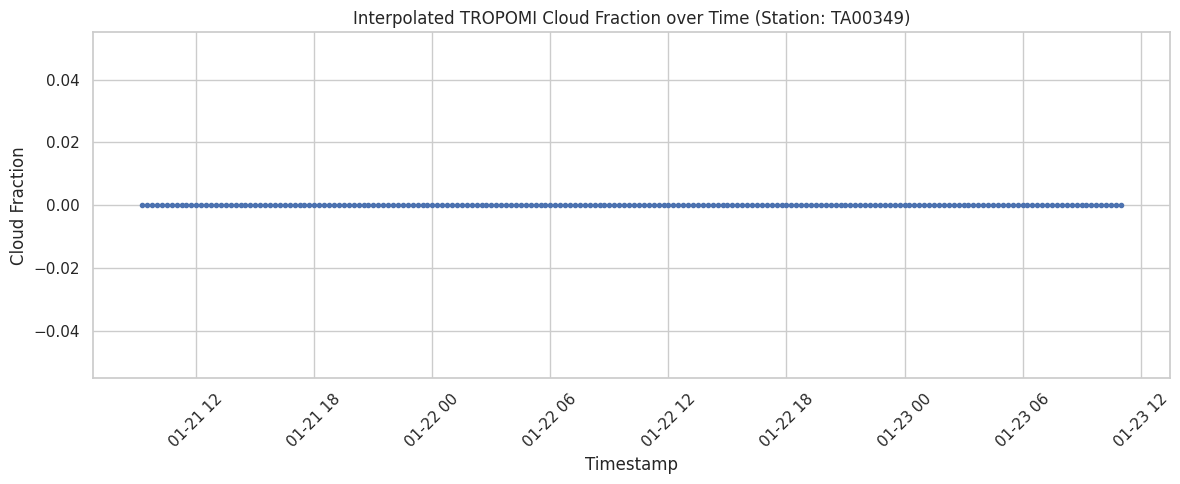

In [9]:
print("--- Visualizing Cloud Fraction Filling for a Single Station ---")
# Pick a random station to visualize how the daily value was stretched across 15-min intervals
sample_station = train_merged['station'].unique()[0]
sample_data = train_merged[train_merged['station'] == sample_station].iloc[100:300] # Plot 200 consecutive timestamps

plt.figure(figsize=(12, 5))
plt.plot(sample_data['timestamp'], sample_data['cloud_fraction'], marker='o', linestyle='-', color='b', markersize=3)
plt.title(f'Interpolated TROPOMI Cloud Fraction over Time (Station: {sample_station})')
plt.xlabel('Timestamp')
plt.ylabel('Cloud Fraction')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

VERIFYING ROLLING WINDOW (LOCALIZED COVARIATES)

In [10]:
print("--- Calculating and Verifying Rolling Windows ---")
train_sorted = train_merged.sort_values(by=['station', 'timestamp']).reset_index(drop=True)

# Calculate rolling 1-hour (4 periods) and 3-hour (12 periods) means for temperature and humidity
train_sorted['rh_roll1'] = train_sorted.groupby('station')['relativehumidity (-)'].transform(lambda x: x.rolling(4, min_periods=1).mean())
train_sorted['rh_roll3'] = train_sorted.groupby('station')['relativehumidity (-)'].transform(lambda x: x.rolling(12, min_periods=1).mean())
train_sorted['temp_roll1'] = train_sorted.groupby('station')['temperature (degrees Celsius)'].transform(lambda x: x.rolling(4, min_periods=1).mean())
train_sorted['temp_roll3'] = train_sorted.groupby('station')['temperature (degrees Celsius)'].transform(lambda x: x.rolling(12, min_periods=1).mean())

# Verify it mathematically on a small slice
verify_slice = train_sorted[['station', 'timestamp', 'temperature (degrees Celsius)', 'temp_roll1', 'temp_roll3']].head(6)
display(verify_slice)
print("Notice how 'temp_roll1' acts as a cumulative moving average for the first 4 rows, then becomes a sliding window.")


--- Calculating and Verifying Rolling Windows ---


,station,timestamp,temperature (degrees Celsius),temp_roll1,temp_roll3
0,TA00078,2016-01-11 10:30:00,20.4,20.400000,20.400000
1,TA00078,2016-01-11 10:45:00,20.5,20.450000,20.450000
2,TA00078,2016-01-11 11:00:00,20.4,20.433333,20.433333
3,TA00078,2016-01-11 11:15:00,20.5,20.450000,20.450000
4,TA00078,2016-01-11 11:30:00,19.7,20.275000,20.300000
5,TA00078,2016-01-11 11:45:00,20.3,20.225000,20.300000


Notice how 'temp_roll1' acts as a cumulative moving average for the first 4 rows, then becomes a sliding window.


TARGET VARIABLE (RADIATION)

--- Target Variable: Radiation Analysis ---


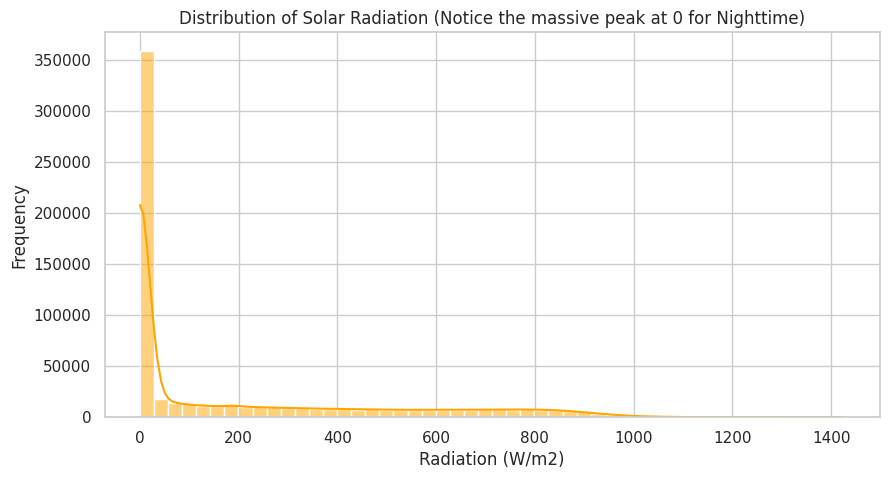

In [11]:
print("--- Target Variable: Radiation Analysis ---")
plt.figure(figsize=(10, 5))
sns.histplot(train_sorted['radiation (W/m2)'], bins=50, kde=True, color='orange')
plt.title('Distribution of Solar Radiation (Notice the massive peak at 0 for Nighttime)')
plt.xlabel('Radiation (W/m2)')
plt.ylabel('Frequency')
plt.show()

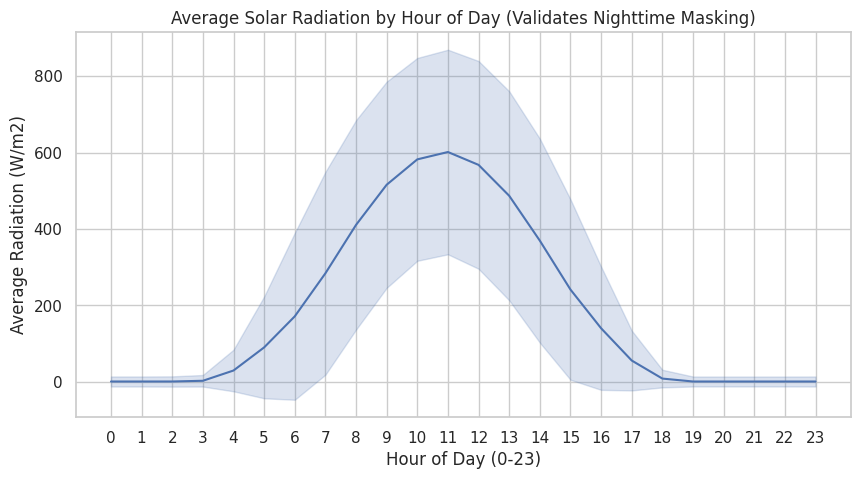

This explicitly verifies why we apply the strict nighttime mask (setting predictions to 0 before 05:00 and after 19:00) in the main pipeline.


In [12]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=train_sorted, x='hour', y='radiation (W/m2)', errorbar='sd')
plt.title('Average Solar Radiation by Hour of Day (Validates Nighttime Masking)')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Average Radiation (W/m2)')
plt.xticks(range(0, 24))
plt.show()
print("This explicitly verifies why we apply the strict nighttime mask (setting predictions to 0 before 05:00 and after 19:00) in the main pipeline.")

Feature Correlation Analysis

--- Feature Correlation Heatmap ---


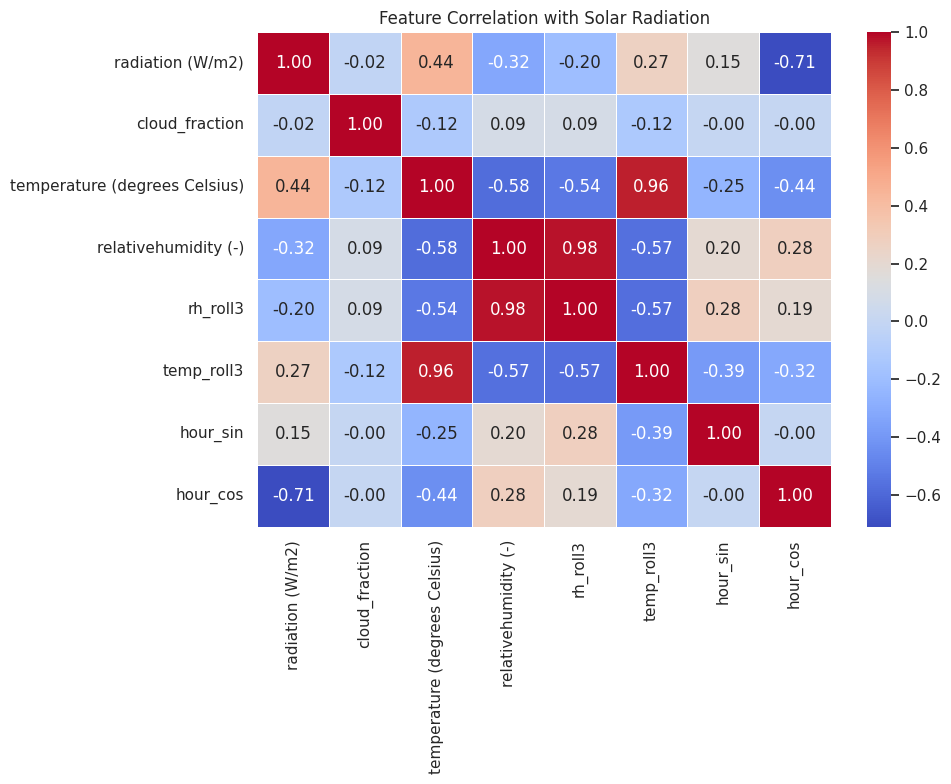

Look for strong negative correlations between 'cloud_fraction' and radiation, and strong positive correlations with 'temperature'.


In [13]:
print("--- Feature Correlation Heatmap ---")
# Select features to evaluate
correlation_features = [
    'radiation (W/m2)', 'cloud_fraction', 'temperature (degrees Celsius)',
    'relativehumidity (-)', 'rh_roll3', 'temp_roll3', 'hour_sin', 'hour_cos'
]

plt.figure(figsize=(10, 8))
corr_matrix = train_sorted[correlation_features].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation with Solar Radiation')
plt.tight_layout()
plt.show()
print("Look for strong negative correlations between 'cloud_fraction' and radiation, and strong positive correlations with 'temperature'.")


Time-Stratified Validation Split (Chronological)

In [14]:
print("--- Creating Time-Stratified Split ---")

# FIX: Ensure 'dayofyear' and 'month' exist
train_sorted['timestamp'] = pd.to_datetime(train_sorted['timestamp'])
train_sorted['dayofyear'] = train_sorted['timestamp'].dt.dayofyear
train_sorted['month'] = train_sorted['timestamp'].dt.month

# The competition organizers ALREADY split Train (odd months) and Test (even months).
# Since the Train dataset ONLY contains odd months (1, 3, 5, 7, 9, 11),
# splitting by even months here results in an EMPTY validation set.
# Instead, let's use the last available month (November / Month 11) as our local validation set.
train_mask = train_sorted['month'] < 11
val_mask = train_sorted['month'] == 11

# Separate features and target
features = [
    'precipitation (mm)', 'relativehumidity (-)', 'temperature (degrees Celsius)',
    'hour_sin', 'hour_cos', 'dayofyear', 'cloud_fraction',
    'rh_roll1', 'rh_roll3', 'temp_roll1', 'temp_roll3'
]
target = 'radiation (W/m2)'

X_train_strat = train_sorted.loc[train_mask, features]
y_train_strat = train_sorted.loc[train_mask, target]
X_val_strat = train_sorted.loc[val_mask, features]
y_val_strat = train_sorted.loc[val_mask, target]

print(f"Training set shape:   {X_train_strat.shape}")
print(f"Validation set shape: {X_val_strat.shape}")



--- Creating Time-Stratified Split ---
Training set shape:   (527094, 11)
Validation set shape: (115081, 11)


**5-Fold Cross Validation Setup & Teacher Training**

In [15]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import lightgbm as lgb
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error
import lightgbm as lgb
import numpy as np

In [16]:
print("--- Training the 'Teacher' Model using GroupKFold (No Leakage) ---")

from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error
import lightgbm as lgb
import numpy as np

# Spatial features restored here
features = [
    'precipitation (mm)', 'relativehumidity (-)', 'temperature (degrees Celsius)',
    'installation_height', 'elevation', 'latitude', 'longitude',
    'hour_sin', 'hour_cos', 'dayofyear', 'cloud_fraction',
    'rh_roll1', 'rh_roll3', 'temp_roll1', 'temp_roll3'
]
target = 'radiation (W/m2)'

X_train_full = train_sorted[features]
y_train_full = train_sorted[target]
groups = train_sorted['month']

# Setup GroupKFold to prevent Time-Series Data Leakage
n_splits = train_sorted['month'].nunique()
gkf = GroupKFold(n_splits=n_splits)
models = []
oof_preds = np.zeros(len(X_train_full))
feature_importances = np.zeros(len(features))

def custom_eval(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mbe = np.mean(y_pred - y_true)
    combined_loss = (0.5 * rmse) + (0.5 * np.abs(mbe))
    return 'custom_rmse_mbe', combined_loss, False

for fold, (train_idx, val_idx) in enumerate(gkf.split(X_train_full, y_train_full, groups=groups)):
    print(f"\n--- Training Fold {fold + 1} ---")
    X_tr, y_tr = X_train_full.iloc[train_idx], y_train_full.iloc[train_idx]
    X_va, y_va = X_train_full.iloc[val_idx], y_train_full.iloc[val_idx]

    model = lgb.LGBMRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=8,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        eval_metric=custom_eval,
        callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)]
    )

    models.append(model)

    # Predict on validation fold
    val_preds = model.predict(X_va)

    # Apply physics-based nighttime mask to validation fold
    val_hours = train_sorted.iloc[val_idx]['hour'] + train_sorted.iloc[val_idx]['minute'] / 60.0
    night_mask = (val_hours < 5.0) | (val_hours > 19.0)
    val_preds = np.clip(val_preds, 0, None)
    val_preds[night_mask] = 0.0

    oof_preds[val_idx] = val_preds
    feature_importances += model.feature_importances_ / n_splits

    fold_rmse = np.sqrt(mean_squared_error(y_va, val_preds))
    print(f"Fold {fold + 1} RMSE: {fold_rmse:.2f} W/m2")

--- Training the 'Teacher' Model using GroupKFold (No Leakage) ---

--- Training Fold 1 ---
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.066254 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2324
[LightGBM] [Info] Number of data points in the train set: 523139, number of used features: 15
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 189.908242
Fold 1 RMSE: 90.79 W/m2

--- Training Fold 2 ---
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.071079 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2299
[LightGBM] [Info] Number of data points in the train set: 523878, number of us

**Validation Performance (Out-Of-Fold) & Residual Analysis**


--- Overall 5-Fold Validation Performance ---
Overall OOF RMSE: 92.66 W/m2
Overall OOF MBE:  -2.55 W/m2


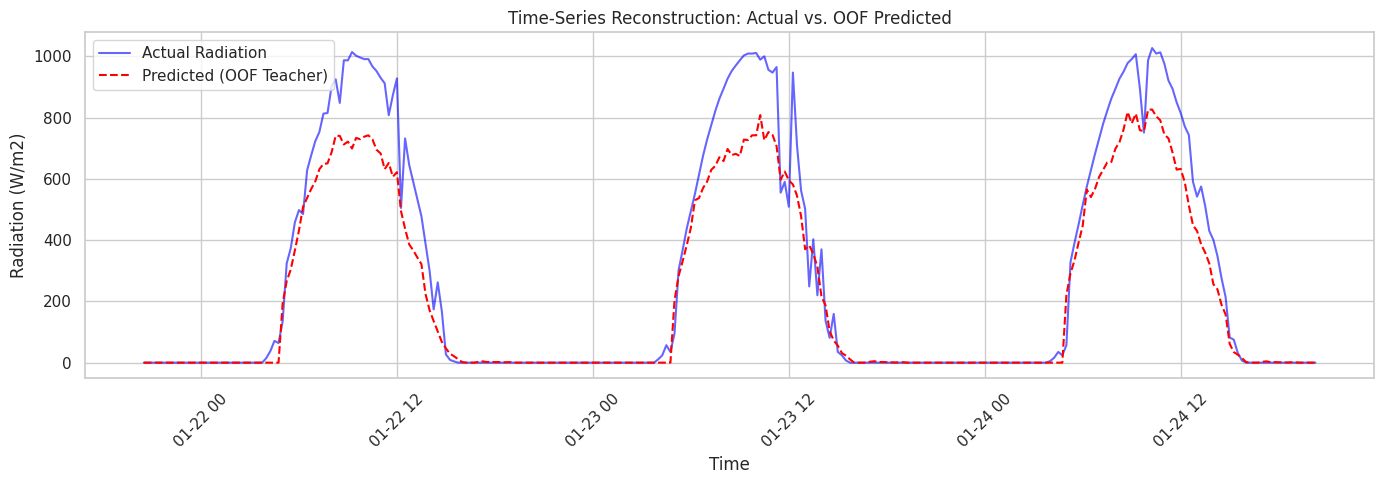

In [17]:
print("\n--- Overall 5-Fold Validation Performance ---")

final_oof_rmse = np.sqrt(mean_squared_error(y_train_full, oof_preds))
final_oof_mbe = np.mean(oof_preds - y_train_full)

print(f"Overall OOF RMSE: {final_oof_rmse:.2f} W/m2")
print(f"Overall OOF MBE:  {final_oof_mbe:.2f} W/m2")

# Plot Actual vs Predicted for a random window
sample_idx = range(1000, 1288)
sample_val = train_sorted.iloc[sample_idx]
sample_preds = oof_preds[sample_idx]

plt.figure(figsize=(14, 5))
plt.plot(sample_val['timestamp'], sample_val['radiation (W/m2)'], label='Actual Radiation', color='blue', alpha=0.6)
plt.plot(sample_val['timestamp'], sample_preds, label='Predicted (OOF Teacher)', color='red', linestyle='--')
plt.title('Time-Series Reconstruction: Actual vs. OOF Predicted')
plt.xlabel('Time')
plt.ylabel('Radiation (W/m2)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



** Test Set Inference & 5-Fold Ensemblinga**

In [18]:
print("\n--- Preparing Test Data and Generating Ensembled Final Submission ---")

# 1. Merge TROPOMI and interpolate for the test set
test_merged = test_time.merge(tropomi_clean, on=['station', 'date'], how='left')
test_merged['cloud_fraction'] = test_merged.groupby('station')['cloud_fraction'].ffill().bfill().fillna(0)

# 2. Sort and calculate rolling windows for test set
test_sorted = test_merged.sort_values(by=['station', 'timestamp']).reset_index(drop=True)
test_sorted['rh_roll1'] = test_sorted.groupby('station')['relativehumidity (-)'].transform(lambda x: x.rolling(4, min_periods=1).mean())
test_sorted['rh_roll3'] = test_sorted.groupby('station')['relativehumidity (-)'].transform(lambda x: x.rolling(12, min_periods=1).mean())
test_sorted['temp_roll1'] = test_sorted.groupby('station')['temperature (degrees Celsius)'].transform(lambda x: x.rolling(4, min_periods=1).mean())
test_sorted['temp_roll3'] = test_sorted.groupby('station')['temperature (degrees Celsius)'].transform(lambda x: x.rolling(12, min_periods=1).mean())

# 3. Add 'dayofyear' specifically to test_sorted
test_sorted['timestamp'] = pd.to_datetime(test_sorted['timestamp'])
test_sorted['dayofyear'] = test_sorted['timestamp'].dt.dayofyear
test_sorted['month'] = test_sorted['timestamp'].dt.month

# 4. Extract features
X_test_final = test_sorted[features]

# 5. Predict using ALL trained Teacher models (Ensembling)
print("Generating predictions using GroupKFold Ensembling...")
test_preds_list = []
for i, model in enumerate(models):
    print(f"Predicting with Fold {i+1}...")
    test_preds_list.append(model.predict(X_test_final))

# Average the predictions across all folds
test_preds_avg = np.mean(test_preds_list, axis=0)

# 6. Apply physics-based nighttime mask
test_hours = test_sorted['hour'] + test_sorted['minute'] / 60.0
test_night_mask = (test_hours < 5.0) | (test_hours > 19.0)
test_preds_avg = np.clip(test_preds_avg, 0, None)
test_preds_avg[test_night_mask] = 0.0

# 7. Format submission
print("Formatting submission file...")
sample_sub = pd.read_csv('/content/drive/MyDrive/TAHMO Incoming Solar Radiation Prediction Challenge/Test.csv')

submission_df = pd.DataFrame({
    'ID': test_sorted['ID'],
    'TargetMBE': test_preds_avg,
    'TargetRMSE': test_preds_avg
})

# Ensure chronological order matches SampleSubmission exactly
final_submission = sample_sub[['ID']].merge(submission_df, on='ID', how='left')

# Save to CSV
final_submission.to_csv('final_submission_groupkfold.csv', index=False)
print("Success! 'final_submission_groupkfold.csv' generated and ready for Zindi.")
display(final_submission.head())


--- Preparing Test Data and Generating Ensembled Final Submission ---
Generating predictions using GroupKFold Ensembling...
Predicting with Fold 1...
Predicting with Fold 2...
Predicting with Fold 3...
Predicting with Fold 4...
Predicting with Fold 5...
Predicting with Fold 6...
Formatting submission file...
Success! 'final_submission_groupkfold.csv' generated and ready for Zindi.


,ID,TargetMBE,TargetRMSE
0,e1ca667d_2017-02_6DN3R0,0.0,0.0
1,e1ca667d_2017-02_CA6DZ7,0.0,0.0
2,e1ca667d_2017-02_3UJPYF,0.0,0.0
3,e1ca667d_2017-02_PKCTGW,0.0,0.0
4,e1ca667d_2017-02_7GFGDR,0.0,0.0


***Station-by-Station Ensemble + Solar Geometry***

In [19]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import xgboost as xgb
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

print("--- Step 1: Calculating Solar Geometry (SZA) ---")
# Calculating Solar Zenith Angle (SZA) based on latitude, day, and time
def add_solar_geometry(df):
    lat_rad = np.radians(df['latitude'])

    # Declination angle (varies by day of year)
    # 23.44 is the Earth's axial tilt. Day 81 is roughly the Spring Equinox.
    declination_deg = 23.44 * np.sin(np.radians((360 / 365.0) * (df['dayofyear'] - 81)))
    declination_rad = np.radians(declination_deg)

    # Hour angle (varies by time of day)
    time_in_hours = df['hour'] + df['minute'] / 60.0
    hour_angle_deg = 15.0 * (time_in_hours - 12.0)
    hour_angle_rad = np.radians(hour_angle_deg)

    # Cosine of Solar Zenith Angle
    df['cos_sza'] = (np.sin(lat_rad) * np.sin(declination_rad) +
                     np.cos(lat_rad) * np.cos(declination_rad) * np.cos(hour_angle_rad))

    # Actual Solar Zenith Angle in degrees
    df['sza'] = np.degrees(np.arccos(np.clip(df['cos_sza'], -1.0, 1.0)))
    return df

train_sorted = add_solar_geometry(train_sorted)
test_sorted = add_solar_geometry(test_sorted)

--- Step 1: Calculating Solar Geometry (SZA) ---


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error

--- Step 2: Setting up Advanced Per-Station Training with Evaluation ---
Total Stations to process: 40

[1/40] Training models for Station: TA00078...
[2/40] Training models for Station: TA00109...
[3/40] Training models for Station: TA00117...
[4/40] Training models for Station: TA00118...
[5/40] Training models for Station: TA00119...
[6/40] Training models for Station: TA00121...
[7/40] Training models for Station: TA00122...
[8/40] Training models for Station: TA00123...
[9/40] Training models for Station: TA00134...
[10/40] Training models for Station: TA00325...
[11/40] Training models for Station: TA00328...
[12/40] Training models for Station: TA00330...
[13/40] Training models for Station: TA00331...
[14/40] Training models for Station: TA00333...
[15/40] Training models for Station: TA00334...
[16/40] Training models for Station: TA00335...
[17/40] Training models for Station: TA00336...
[18/40] Training models for Station: TA00337...
[19/40] Training models for Station: TA00

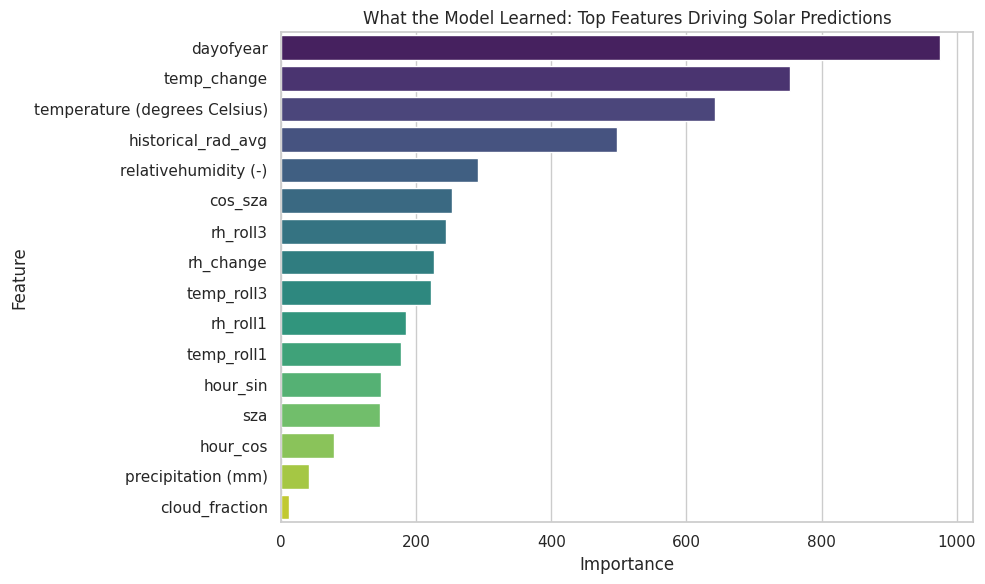

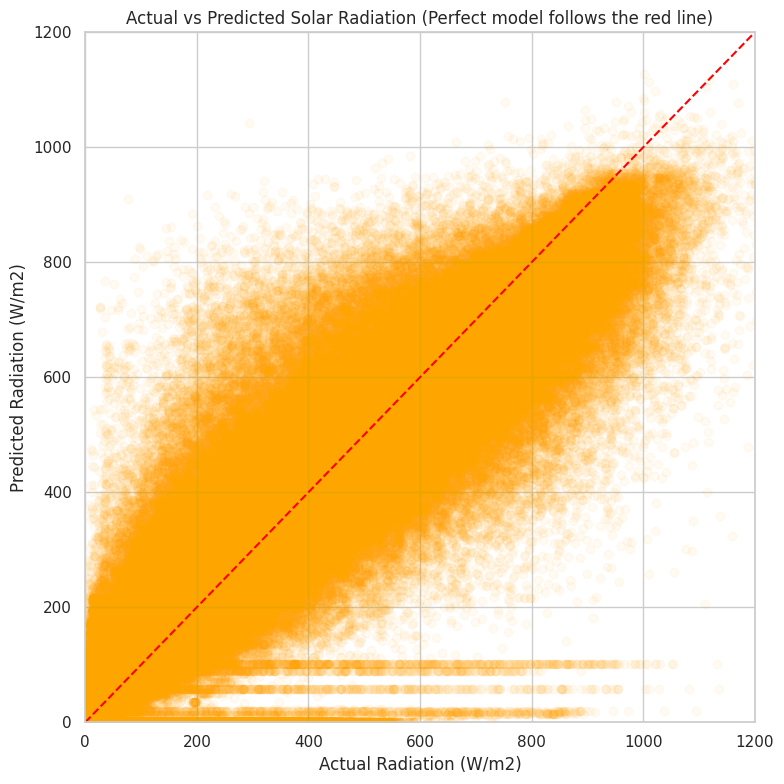

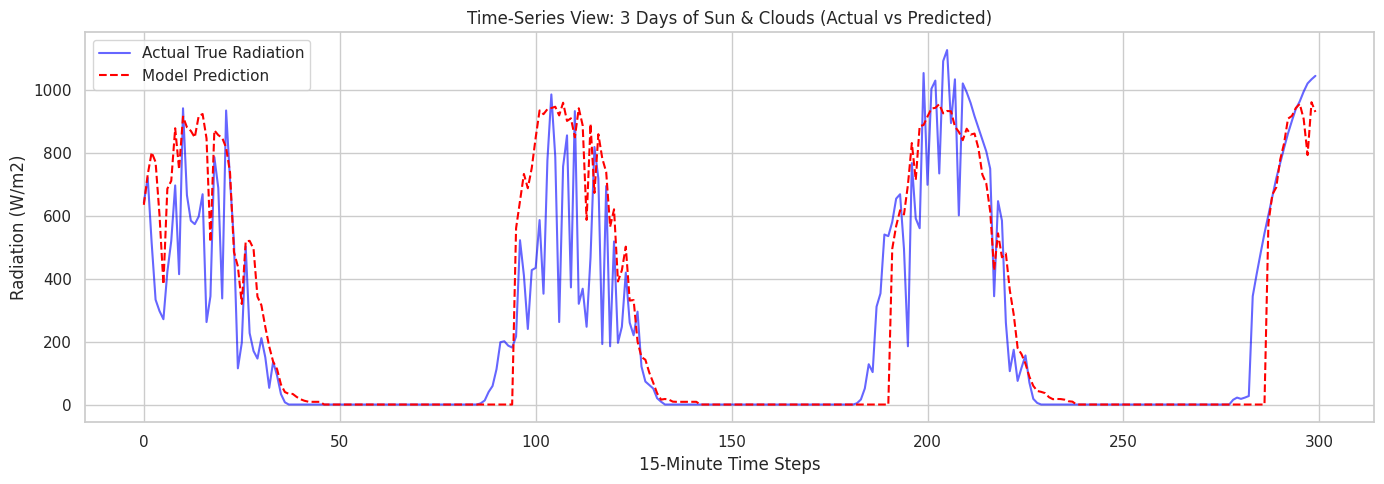


--- Step 3: Formatting Final Station-by-Station Submission ---
Success! 'final_per_station_advanced_features.csv' generated.


In [21]:
# =============================================================================
# THE BIG LOOP WITH VALIDATION METRICS & GRAPHS
# =============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error

print("--- Step 2: Setting up Advanced Per-Station Training with Evaluation ---")

features = [
    'precipitation (mm)', 'relativehumidity (-)', 'temperature (degrees Celsius)',
    'hour_sin', 'hour_cos', 'dayofyear', 'cloud_fraction',
    'rh_roll1', 'rh_roll3', 'temp_roll1', 'temp_roll3',
    'cos_sza', 'sza',
    'historical_rad_avg', 'temp_change', 'rh_change'
]
target = 'radiation (W/m2)'

all_test_predictions = []
test_ids = []

# TO TRACK VALIDATION PERFORMANCE
all_y_true = []
all_y_val_pred = []
feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': 0.0})

stations = train_sorted['station'].unique()
total_stations = len(stations)
print(f"Total Stations to process: {total_stations}\n")

for i, station in enumerate(stations):
    print(f"[{i+1}/{total_stations}] Training models for Station: {station}...")

    # 1. Filter Train and Test data
    train_station = train_sorted[train_sorted['station'] == station].copy().reset_index(drop=True)
    test_station = test_sorted[test_sorted['station'] == station].copy().reset_index(drop=True)

    if len(test_station) == 0:
        continue

    # --- FEATURE ENGINEERING INSIDE THE LOOP ---
    time_group = train_station.groupby(['hour', 'minute'])[target].mean().reset_index()
    time_group.rename(columns={target: 'historical_rad_avg'}, inplace=True)

    train_station = train_station.merge(time_group, on=['hour', 'minute'], how='left')
    test_station = test_station.merge(time_group, on=['hour', 'minute'], how='left')
    test_station['historical_rad_avg'].fillna(train_station['historical_rad_avg'].mean(), inplace=True)

    train_station['temp_change'] = train_station['temperature (degrees Celsius)'] - train_station['temp_roll1']
    train_station['rh_change'] = train_station['relativehumidity (-)'] - train_station['rh_roll1']

    test_station['temp_change'] = test_station['temperature (degrees Celsius)'] - test_station['temp_roll1']
    test_station['rh_change'] = test_station['relativehumidity (-)'] - test_station['rh_roll1']

    X_train_stat = train_station[features]
    y_train_stat = train_station[target]
    groups_stat = train_station['month']
    X_test_stat = test_station[features]

    # Validation Setup
    n_splits = train_station['month'].nunique()
    if n_splits < 2:
        from sklearn.model_selection import KFold
        gkf = KFold(n_splits=3, shuffle=True, random_state=42)
        cv_splitter = list(gkf.split(X_train_stat))
    else:
        from sklearn.model_selection import GroupKFold
        gkf = GroupKFold(n_splits=n_splits)
        cv_splitter = list(gkf.split(X_train_stat, y_train_stat, groups=groups_stat))

    lgbm_station_preds = []
    xgb_station_preds = []

    # Array to hold out-of-fold validation predictions for this station
    stat_val_preds = np.zeros(len(train_station))

    for train_idx, val_idx in cv_splitter:
        X_tr, y_tr = X_train_stat.iloc[train_idx], y_train_stat.iloc[train_idx]
        X_va, y_va = X_train_stat.iloc[val_idx], y_train_stat.iloc[val_idx]

        # LightGBM
        lgb_model = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.03, max_depth=6, random_state=42, verbose=-1, n_jobs=-1)
        lgb_model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], callbacks=[lgb.early_stopping(40, verbose=False)])

        # XGBoost
        xgb_model = xgb.XGBRegressor(n_estimators=300, learning_rate=0.03, max_depth=5, random_state=42, n_jobs=-1, early_stopping_rounds=40, tree_method='hist')
        xgb_model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)

        # Validation Prediction (Ensemble)
        val_pred_fold = (0.5 * lgb_model.predict(X_va)) + (0.5 * xgb_model.predict(X_va))

        # Apply Night Mask to Validation
        night_mask_val = X_va['sza'] >= 89.5
        val_pred_fold = np.clip(val_pred_fold, 0, None)
        val_pred_fold[night_mask_val] = 0.0

        stat_val_preds[val_idx] = val_pred_fold

        # Track Feature Importances
        feature_importance_df['Importance'] += lgb_model.feature_importances_ / (len(cv_splitter) * total_stations)

        # Test Set Predictions
        lgbm_station_preds.append(lgb_model.predict(X_test_stat))
        xgb_station_preds.append(xgb_model.predict(X_test_stat))

    # Save Ground Truth and Validation Predictions for global metrics
    all_y_true.extend(y_train_stat.values)
    all_y_val_pred.extend(stat_val_preds)

    # Average Test predictions for this station
    stat_ensemble_preds = (0.5 * np.mean(lgbm_station_preds, axis=0)) + (0.5 * np.mean(xgb_station_preds, axis=0))

    # Physics Test Mask
    night_mask = test_station['sza'] >= 89.5
    stat_ensemble_preds = np.clip(stat_ensemble_preds, 0, None)
    stat_ensemble_preds[night_mask] = 0.0

    test_ids.extend(test_station['ID'].tolist())
    all_test_predictions.extend(stat_ensemble_preds.tolist())

# =============================================================================
# EVALUATION METRICS & VISUALIZATIONS
# =============================================================================
print("\n" + "="*50)
print("🏆 LOCAL VALIDATION RESULTS (OUT-OF-FOLD) 🏆")
print("="*50)

overall_rmse = np.sqrt(mean_squared_error(all_y_true, all_y_val_pred))
overall_mbe = np.mean(np.array(all_y_val_pred) - np.array(all_y_true))

print(f"Overall Validation RMSE : {overall_rmse:.2f} W/m2")
print(f"Overall Validation MBE  : {overall_mbe:.2f} W/m2")
print("="*50)

sns.set_theme(style="whitegrid")

# Graph 1: Feature Importance
plt.figure(figsize=(10, 6))
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title("What the Model Learned: Top Features Driving Solar Predictions")
plt.tight_layout()
plt.show()

# Graph 2: Scatter Plot (Actual vs Predicted)
plt.figure(figsize=(8, 8))
plt.scatter(all_y_true, all_y_val_pred, alpha=0.05, color='orange')
plt.plot([0, 1200], [0, 1200], color='red', linestyle='--') # Perfect prediction line
plt.title("Actual vs Predicted Solar Radiation (Perfect model follows the red line)")
plt.xlabel("Actual Radiation (W/m2)")
plt.ylabel("Predicted Radiation (W/m2)")
plt.xlim(0, 1200)
plt.ylim(0, 1200)
plt.tight_layout()
plt.show()

# Graph 3: Time Series Snippet (A look at 3 Days of predictions)
plt.figure(figsize=(14, 5))
plt.plot(all_y_true[2000:2300], label='Actual True Radiation', color='blue', alpha=0.6)
plt.plot(all_y_val_pred[2000:2300], label='Model Prediction', color='red', linestyle='--')
plt.title("Time-Series View: 3 Days of Sun & Clouds (Actual vs Predicted)")
plt.ylabel("Radiation (W/m2)")
plt.xlabel("15-Minute Time Steps")
plt.legend()
plt.tight_layout()
plt.show()

# =============================================================================
# FORMAT FINAL SUBMISSION (PURE MODEL PREDICTIONS)
# =============================================================================
print("\n--- Step 3: Formatting Final Station-by-Station Submission ---")

# Hum yahan koi manual bias correction nahi kar rahe hain.
# Model ne jo predict kiya hai, wahi final hai!
results_df = pd.DataFrame({
    'ID': test_ids,
    'TargetMBE': all_test_predictions,
    'TargetRMSE': all_test_predictions
})



try:
    sample_sub = pd.read_csv('/content/drive/MyDrive/TAHMO Incoming Solar Radiation Prediction Challenge/Test.csv')
    if 'TargetMBE' not in sample_sub.columns:
        sample_sub = pd.read_csv('/content/drive/MyDrive/TAHMO Incoming Solar Radiation Prediction Challenge/SampleSubmission (1).csv')
except:
    sample_sub = pd.read_csv('/content/drive/MyDrive/TAHMO Incoming Solar Radiation Prediction Challenge/SampleSubmission (1).csv')

final_submission = sample_sub[['ID']].merge(results_df, on='ID', how='left')
final_submission.to_csv('final_per_station_advanced_features.csv', index=False)
print("Success! 'final_per_station_advanced_features.csv' generated.")